<h1 style="text-align: center;">SMT Challenge 2025 Bayesian Analysis</h1>
<h3 style="text-align: center;"><i>Team 15</i> - this notebook is used to conduct the Bayesian Analysis of the data + the quantification of Aggressiveness</h3>

### Necessary Libraries

In [681]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

baby_blue_color = '#89CFF0'
red_color = '#CC3433'

pd.set_option('display.max_columns', None)

### Helper Functions

In [132]:
home_field_dim = {'QEA': {
                            'outfield_wall': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/310) * (x)**2) + 400, lambda x: -((1/395) * (x)**2) + 400]), 
                            'warning_track': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/240) * (x)**2) + 384, lambda x: -((1/325) * (x)**2) + 384])
                            },
                    'RZQ': {
                            'outfield_wall': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/380) * (x-60)**2) + 415, lambda x: -((1/340) * (x)**2) + 405]), 
                            'warning_track': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/310) * (x-60)**2) + 399, lambda x: -((1/270) * (x)**2) + 389])
                            },
                    'YJD': {
                            'outfield_wall': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/300) * (x)**2) + 415, lambda x: -((1/288) * (x)**2) + 417]), 
                            'warning_track': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/230) * (x)**2) + 399, lambda x: -((1/235) * (x)**2) + 401])
                            }
                }

In [741]:
def dist_closest_teammate(df: pd.DataFrame, game_str_id: str):
    """
    Finds the distance of the closest teammate to the person who made the attempt at the point 1.5 sec before the landing/catch pt
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## figures out who gets credit for the route (meaning they made the catch or were the closest to the ball)
    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
            if game_str_id in not_aggressive_list:
                return 0
        else:
            catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
            if game_str_id in not_aggressive_list:
                return 0
        else:
            catch_point = catch_point.iloc[0]

    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = int(catch_point['player_position'])
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = int(sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0])

    ## looks at the 1.5 sec point to see how far the closest fielder is to the fielder who made the attempt
    catch_time = catch_point['elapsed_timestamp']
    one_half_s_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time-1.5, 1)]['elapsed_timestamp'] - round(catch_time-1.5, 1)).idxmin()
    df = df.iloc[one_half_s_marker]

    dist_fielders = {}
    if nearest_to_catch_pt == 7:
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 8:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 9:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])

    return min(dist_fielders.values())

In [740]:
def direction_closest_teammate(df: pd.DataFrame, game_str_id: str):
    """
    Finds the direction of the closest teammate to the person who made the attempt at the point 1.5 sec before the landing/catch pt
    Uses the same direction reasoning as direction angle in the EDA notebook
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## figures out who gets credit for the route (meaning they made the catch or were the closest to the ball)
    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
            if game_str_id in not_aggressive_list:
                return 0
        else:
            catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
            if game_str_id in not_aggressive_list:
                return 0
        else:
            catch_point = catch_point.iloc[0]

    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = int(catch_point['player_position'])
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = int(sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0])

    ## looks at the 1.5 sec point to see how far the closest fielder is to the fielder who made the attempt
    catch_time = catch_point['elapsed_timestamp']
    one_half_s_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time-1.5, 1)]['elapsed_timestamp'] - round(catch_time-1.5, 1)).idxmin()
    df = df.iloc[one_half_s_marker]

    dist_fielders = {}
    if nearest_to_catch_pt == 7:
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 8:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 9:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])

    closest_teammate_pos = min(dist_fielders, key=dist_fielders.get)

    direct_fielders = {}
    if nearest_to_catch_pt == 7:
        direct_fielders[8] = update_angle(np.degrees((math.atan2(df['field_y_8'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_8'] - df[f'field_x_{nearest_to_catch_pt}']))))
        direct_fielders[9] = update_angle(np.degrees((math.atan2(df['field_y_9'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_9'] - df[f'field_x_{nearest_to_catch_pt}']))))
    if nearest_to_catch_pt == 8:
        direct_fielders[7] = update_angle(np.degrees((math.atan2(df['field_y_7'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_7'] - df[f'field_x_{nearest_to_catch_pt}']))))
        direct_fielders[9] = update_angle(np.degrees((math.atan2(df['field_y_9'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_9'] - df[f'field_x_{nearest_to_catch_pt}']))))
    if nearest_to_catch_pt == 9:
        direct_fielders[7] = update_angle(np.degrees((math.atan2(df['field_y_7'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_7'] - df[f'field_x_{nearest_to_catch_pt}']))))
        direct_fielders[8] = update_angle(np.degrees((math.atan2(df['field_y_8'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_8'] - df[f'field_x_{nearest_to_catch_pt}']))))

    return direct_fielders[closest_teammate_pos]

In [742]:
def closest_teammate(df: pd.DataFrame, game_str_id: str):
    """
    Finds the closest teammate to the person who made the attempt at the point 1.5 sec before the landing/catch pt
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## figures out who gets credit for the route (meaning they made the catch or were the closest to the ball)
    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
            if game_str_id in not_aggressive_list:
                return 0
        else:
            catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
            if game_str_id in not_aggressive_list:
                return 0
        else:
            catch_point = catch_point.iloc[0]

    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = int(catch_point['player_position'])
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = int(sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0])

    ## looks at the 1.5 sec point to see how far the closest fielder is to the fielder who made the attempt
    catch_time = catch_point['elapsed_timestamp']
    one_half_s_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time-1.5, 1)]['elapsed_timestamp'] - round(catch_time-1.5, 1)).idxmin()
    df = df.iloc[one_half_s_marker]

    dist_fielders = {}
    if nearest_to_catch_pt == 7:
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 8:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 9:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])

    return min(dist_fielders, key=dist_fielders.get)

In [688]:
def update_angle(direction_angle: float) -> str:
    """
    Helper function made to transform the direction angle between each an outfielder's position and the catch point
    Matches the description of 0º being in front and 180º in the back (following a clockwise motion starting from 0º)
    
    Arguments: direction_angle: an outfielder's direction angle towards the catch point based on the unit circle
    """
    if direction_angle < 0:
        direction_angle = direction_angle + 360
    if (0 <= direction_angle < 60) or (direction_angle==360):
        return 'Back Right'
    elif 60 <= direction_angle < 120:
        return 'Back'
    elif 120 <= direction_angle < 180:
        return 'Back Left'
    elif 180 <= direction_angle < 240:
        return 'In Left'
    elif 240 <= direction_angle < 300:
        return 'In'
    elif 300 <= direction_angle < 360:
        return 'In Right'

In [649]:
def jump_hists(df: pd.DataFrame, jump_metric: str) -> None:
    """
    Plots the histogram of each jump component vs avg
    
    Arguments: df: Dataframe, jump_metric: one of the jump metrics (vs avg)
    """
    plt.figure()
    sns.histplot(data=df, x=jump_metric, bins=20, color=baby_blue_color, stat='density')
    sns.kdeplot(data=df, x=jump_metric, color=red_color)
    plt.title(f'{jump_metric} Distribution')
    plt.show()

In [600]:
def aggressive_attempt(df: pd.DataFrame, game_str_id: str) -> int:
    """
    Dictates whether if game_str_id contains an aggressive attempt
    An aggressive attempt is defined as an outfielder putting their body on the line (e.g., diving, sliding, running into the wall)
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()
    
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    ## automatically makes plays that aren't possible for fielders to catch on the first bounce a 0 (it wasn't possible for them to make an aggressive play on the ball)
    p_catch_zero = (play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['p_catch'] == 0).iloc[0]
    distance_needed_zero = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_needed'].iloc[0]
    distance_traveled_zero = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_traveled'].iloc[0]
    distance_needed_traveled = distance_traveled_zero / distance_needed_zero
    if p_catch_zero and (distance_needed_traveled < 0.95):
        return 0
    
    ## makes sure the difficulty of the play is appropriate to be aggressive for (it filters those flyballs where the fielder slows down to get under the ball)
    ## it's possible that somebody can be aggressive on a 1-2 star level play -> qualification to be aggressive is at least a 3-star level difficulty play
    ## these will most likely not happen often --> without video it's hard to validate aggressiveness on these kind of plays
    valid_p_catch = (play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['p_catch'] > 0.75).iloc[0]
    if valid_p_catch:
        return 0

    ## figures out who gets credit for the route (meaning they made the catch or were the closest to the ball)
    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
            if game_str_id in not_aggressive_list:
                return 0
        else:
            catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
            if game_str_id in not_aggressive_list:
                return 0
        else:
            catch_point = catch_point.iloc[0]

    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = int(catch_point['player_position'])
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = int(sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0])

    df = stepwise_dist_func(df, 7).copy()
    df = stepwise_dist_func(df, 8).copy()
    df = stepwise_dist_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_velo_7'] = df['stepwise_dist_7'] / df['timestamp_diff']#.iloc[1:]
    df.loc[:, 'instantaneous_velo_8'] = df['stepwise_dist_8'] / df['timestamp_diff']#.iloc[1:]
    df.loc[:, 'instantaneous_velo_9'] = df['stepwise_dist_9'] / df['timestamp_diff']#.iloc[1:]

    df = delta_velo_func(df, 7).copy()
    df = delta_velo_func(df, 8).copy()
    df = delta_velo_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_acc_7'] = df['delta_velo_7'] / df['timestamp_diff']#.iloc[2:]
    df.loc[:, 'instantaneous_acc_8'] = df['delta_velo_8'] / df['timestamp_diff']#.iloc[2:]
    df.loc[:, 'instantaneous_acc_9'] = df['delta_velo_9'] / df['timestamp_diff']#.iloc[2:]

    play_catch_prob = (play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['p_catch'].iloc[0] * 100)

    ## looks at the interval around the catch point (1.5 sec before and 0.5 sec after)
    catch_time = catch_point['elapsed_timestamp']
    one_half_s_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time-1.5, 1)]['elapsed_timestamp'] - round(catch_time-1.5, 1)).idxmin()
    if df.iloc[-1]['elapsed_timestamp'] < (catch_time+0.5):
        half_s_after_marker = None
    else:
        half_s_after_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time+0.5, 1)]['elapsed_timestamp'] - round(catch_time+0.5, 1)).idxmin() + 1

    df = df.iloc[one_half_s_marker: half_s_after_marker].reset_index(drop=True).copy()

    first_one_half_s = df.iloc[0: df.loc[(df['event_code'] == idx_dict[0])].iloc[0].name + 1].copy()
    if idx_dict[0] == 2:
        second_half_s = df.iloc[df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))].iloc[0].name:].reset_index(drop=True).copy()
    else:
        second_half_s = df.iloc[df.loc[(df['event_code'] == idx_dict[0])].iloc[0].name:].reset_index(drop=True).copy()

    ## calculates dive/slide
    if (first_one_half_s[f'instantaneous_acc_{nearest_to_catch_pt}'] < -100).any():
        # print(f'{game_str_id}: Dive/Slide, Catch Prob: {play_catch_prob}%')
        return 1
    
    ## calculates running into the wall
    if (second_half_s[f'instantaneous_acc_{nearest_to_catch_pt}'] < -200).any():
        ## takes away the play where the fielder stops their momentum to throw instead of running into the wall
        if (second_half_s[second_half_s['event_code'] == 3].shape[0] >= 1) or ((second_half_s[second_half_s['event_code'] == 8].shape[0] >= 1)):
            return 0
        if (play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_to_wall']).iloc[0] <= 20:
            # print(f'{game_str_id}: Run Into Wall, Catch Prob: {play_catch_prob}%')
            return 1
    
    if game_str_id in aggressive_plays:
        return 1

    return 0

In [334]:
def visual_trajectory(df: pd.DataFrame, game_str_id: str) -> None:
    """
    Displays the route of the outfielder who made the attempt

    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## fixes the game ids that have messed up timestamp intervals and adds in the missing values
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    ## figures out who gets credit for the route (meaning they made the catch or were the closest to the ball)
    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)
    catch_point = df.loc[df['event_code'] == idx_dict[0]].iloc[0]
    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = catch_point['player_position']
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0]
        acquisition_pt = df.loc[(df['event_code'] == 2) & (df['player_position'].isin([7, 8, 9]))].iloc[0]
        acq_x = acquisition_pt[f'field_x_{int(nearest_to_catch_pt)}']
        acq_y = acquisition_pt[f'field_y_{int(nearest_to_catch_pt)}']

    catch_x = catch_point[f'field_x_{int(nearest_to_catch_pt)}']
    catch_y = catch_point[f'field_y_{int(nearest_to_catch_pt)}']
    starting_x = df[f'field_x_{int(nearest_to_catch_pt)}'].iloc[0]
    starting_y = df[f'field_y_{int(nearest_to_catch_pt)}'].iloc[0]
    catch_time = catch_point['elapsed_timestamp']

    one_half_s_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time-1.5, 1)]['elapsed_timestamp'] - round(catch_time-1.5, 1)).idxmin()
    one_half_s_marker_x = df.iloc[one_half_s_marker][f'field_x_{int(nearest_to_catch_pt)}']
    one_half_s_marker_y = df.iloc[one_half_s_marker][f'field_y_{int(nearest_to_catch_pt)}']

    if int(nearest_to_catch_pt) == 7:
        player_pos = 'Left Fielder'
    elif int(nearest_to_catch_pt) == 8:
        player_pos = 'Center Fielder'
    elif int(nearest_to_catch_pt) == 9:
        player_pos = 'Right Fielder'

    home_team = df[df['home_team'].notna()]['home_team'].unique()[0]
    if home_team == 'QEA':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    elif home_team == 'RZQ':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    else:
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)

    lf_x_values = np.linspace(0, -320)
    lf_foul_line = -lf_x_values
    rf_x_values = np.linspace(0, 320)
    rf_foul_line = rf_x_values

    plt.figure()
    sns.scatterplot(data=df, x=f'field_x_{int(nearest_to_catch_pt)}', y=f'field_y_{int(nearest_to_catch_pt)}', color='#89CFF0', s=75)
    if idx_dict[0] == 2:
        plt.scatter(catch_x, catch_y, color='#228B22', s=75, zorder=5, label='Catch Made')
        plt.scatter(one_half_s_marker_x, one_half_s_marker_y, color='black', s=50, zorder=5, label='1.5 Sec Mark Before Catch')
    else:
        plt.scatter(catch_x, catch_y, color='#CC3433', s=75, zorder=5, label='Landing Point')
        plt.scatter(one_half_s_marker_x, one_half_s_marker_y, color='black', s=50, zorder=5, label='1.5 Sec Mark Before Landing')
        plt.scatter(acq_x, acq_y, color='#228B22', s=50, zorder=5, label='Acquisition Point')
    plt.scatter(starting_x, starting_y, color='#0e3386', s=50, zorder=5, label='Starting Point')
    catch_prob_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['p_catch'].iloc[0] * 100
    distance_needed_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_needed'].iloc[0]
    distance_to_wall_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_to_wall'].iloc[0]
    opportunity_time_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['opportunity_time'].iloc[0]
    plt.annotate(f'Catch Prob: {catch_prob_text}%', (catch_x, catch_y), textcoords="offset points", xytext=(50, -20), ha='center')
    plt.annotate(f'Distance Needed: {round(distance_needed_text)} ft', (catch_x, catch_y), textcoords="offset points", xytext=(50, -35), ha='center')
    plt.annotate(f'Distance to Wall: {round(distance_to_wall_text, 1)} ft', (catch_x, catch_y), textcoords="offset points", xytext=(50, -50), ha='center')
    plt.annotate(f'Opportunity Time: {round(opportunity_time_text, 1)} sec', (catch_x, catch_y), textcoords="offset points", xytext=(50, -65), ha='center')
    plt.plot(field_vals, home_run_wall, c='black', zorder=0, label='Outfield Wall')
    plt.plot(field_vals, warning_track, c='white', zorder=0)
    plt.plot(lf_x_values, lf_foul_line, c='black', zorder=0)
    plt.plot(rf_x_values, rf_foul_line, c='black', zorder=0)
    plt.fill_between(field_vals, home_run_wall, warning_track, color='#765b4c', alpha=0.5, zorder=0, label='Warning Track Zone')
    plt.xlim(df[f'field_x_{int(nearest_to_catch_pt)}'].min()-5, df[f'field_x_{int(nearest_to_catch_pt)}'].max()+5)
    plt.ylim(df[f'field_y_{int(nearest_to_catch_pt)}'].min()-10, df[f'field_y_{int(nearest_to_catch_pt)}'].max()+8)
    plt.title(f"{player_pos}'s Route on Play {game_str_id}")
    plt.legend()
    plt.show()

    plot_velo_acc(df, game_str_id, int(nearest_to_catch_pt))

In [542]:
def plot_velo_acc(df: pd.DataFrame, game_str_id: str, position: int) -> None:
    """
    Finds the speed of the player who made the attempt 0.5 sec before and after the catch
    
    Arguments: df: Dataframe, game_str_id: game_str_id, position: outfielder code (7, 8, or 9)
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()
    
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]

    df = stepwise_dist_func(df, 7).copy()
    df = stepwise_dist_func(df, 8).copy()
    df = stepwise_dist_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_velo_7'] = df['stepwise_dist_7'] / df['timestamp_diff'].iloc[1:]
    df.loc[:, 'instantaneous_velo_8'] = df['stepwise_dist_8'] / df['timestamp_diff'].iloc[1:]
    df.loc[:, 'instantaneous_velo_9'] = df['stepwise_dist_9'] / df['timestamp_diff'].iloc[1:]

    df = delta_velo_func(df, 7).copy()
    df = delta_velo_func(df, 8).copy()
    df = delta_velo_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_acc_7'] = df['delta_velo_7'] / df['timestamp_diff'].iloc[2:]
    df.loc[:, 'instantaneous_acc_8'] = df['delta_velo_8'] / df['timestamp_diff'].iloc[2:]
    df.loc[:, 'instantaneous_acc_9'] = df['delta_velo_9'] / df['timestamp_diff'].iloc[2:]

    catch_point = catch_point['elapsed_timestamp']

    time_contact = df.loc[df['event_code'] == 4]['elapsed_timestamp'].iloc[0]
    one_half_sec_before_catch = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_point-1.5, 1)]['elapsed_timestamp'] - round(catch_point-1.5, 1)).idxmin()
    one_half_s_marker = df.loc[one_half_sec_before_catch]['elapsed_timestamp']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    sns.lineplot(data=df.iloc[1:], x='elapsed_timestamp', y=f'instantaneous_velo_{position}', ax=ax1)
    ax1.axvline(x=time_contact, label='time of contact', c='#0e3386')
    ax1.axvline(x=one_half_s_marker, label='1.5 sec before catch', c='black')
    if idx_dict[0] == 2:
        ax1.axvline(x=catch_point, label='catch point', c='#228B22')
    else:
        ax1.axvline(x=catch_point, label='landing point', c='#CC3433')
    ax1.set_title(f"{position}'s Velocity in Play {game_str_id}")
    sns.lineplot(data=df.iloc[2:], x='elapsed_timestamp', y=f'instantaneous_acc_{position}', ax=ax2)
    ax2.axvline(x=time_contact, label='time of contact', c='#0e3386')
    ax2.axvline(x=one_half_s_marker, label='1.5 sec before catch', c='black')

    if idx_dict[0] == 2:
        ax2.axvline(x=catch_point, label='catch point', c='#228B22')
    else:
        ax2.axvline(x=catch_point, label='landing point', c='#CC3433')

    ax2.set_title(f"{position}'s Acceleration in Play {game_str_id}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [134]:
def stadium_walls(df: pd.DataFrame, home_team: str) -> None:
    """
    Visualizes some form of outline for each team's outfield wall + warning track (QEA, RZQ, YJD)
    I trial and error'd with the exact coefficients in the polynomials for the wall + warning track using the clusters of wall balls and homers

    Arguments: Dataframe, home team's name
    """
    df = df.copy()

    plt.figure(figsize=(8, 8))
    lf_x_values = np.linspace(0, -320)
    lf_foul_line = -lf_x_values
    rf_x_values = np.linspace(0, 320)
    rf_foul_line = rf_x_values

    if home_team == 'QEA':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    elif home_team == 'RZQ':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    else:
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)

    stadium_wall_balls = df[(df['event_code_name'] == 'ball deflection off of wall') & (df['home_team'] == home_team)]

    plt.plot(lf_x_values, lf_foul_line, c='red')
    plt.plot(rf_x_values, rf_foul_line, c='red')
    plt.plot(field_vals, home_run_wall, c='red')
    plt.plot(field_vals, warning_track, c='red')
    # plt.ylim(0, 500)
    plt.legend()
    plt.show()

In [30]:
def distance_needed(df: pd.DataFrame, game_str_id: str):
    """
    Calculates the needed distance between the outfielder's position coordinates and the ball's catch point (where it's caught or where it first bounces)
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## fixes the game ids that have messed up timestamp intervals and adds in the missing values
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    ## Each outfielder's starting position (player_pos_x, player_pos_y)
    starting_coords = df.iloc[0]
    lf_starting_coords = starting_coords[['field_x_7', 'field_y_7']]
    cf_starting_coords = starting_coords[['field_x_8', 'field_y_8']]
    rf_starting_coords = starting_coords[['field_x_9', 'field_y_9']]

    ## Calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)
    catch_point = df.loc[df['event_code'] == idx_dict[0]].iloc[0][['ball_position_x', 'ball_position_y']]

    play_made_coords = catch_point

    distance_needed_7 = euclidean_distance(lf_starting_coords.iloc[0], lf_starting_coords.iloc[1], play_made_coords.iloc[0], play_made_coords.iloc[1])
    distance_needed_8 = euclidean_distance(cf_starting_coords.iloc[0], cf_starting_coords.iloc[1], play_made_coords.iloc[0], play_made_coords.iloc[1])
    distance_needed_9 = euclidean_distance(rf_starting_coords.iloc[0], rf_starting_coords.iloc[1], play_made_coords.iloc[0], play_made_coords.iloc[1])

    return np.array([distance_needed_7, distance_needed_8, distance_needed_9])

In [5]:
def attempt_metric_creator(df: pd.DataFrame, col_name: str) -> pd.DataFrame:
    """
    Creates the column of a metric in df that has multiple columns for each fielder
    Bases it on who made the attempt (which has been talked about how that works) 
    
    Arguments: df: Dataframe, col_name: some metric with columns for each fielder
    """
    df = df.copy()
    df.loc[:, col_name] = np.where(df['player_attempt'] == 7, 
                                           df[f'{col_name}_7'],
                                           np.where(
                                               df['player_attempt'] == 8, 
                                               df[f'{col_name}_8'], 
                                               np.where(
                                                   df['player_attempt'] == 9, 
                                                   df[f'{col_name}_9'],
                                                   np.nan)))
    return df

In [6]:
def info_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Displays information about the dataframe with # of missing values, unique numbers, datatypes, etc.
    
    Arguments: Dataframe
    """
    df = df.copy()
    dtype = df.dtypes
    num_unique = df.T.apply(lambda x: x.nunique(), axis=1)
    nan_total = df.isnull().sum()
    nan_percent = (df.isnull().sum()/df.isnull().count()*100)
    quality_df = pd.concat([nan_total, nan_percent, num_unique, dtype], axis=1, keys=['total_NaNs', 'NaN%', 'num_unique', 'dtypes'])
    display(quality_df)

In [7]:
def metric_into_dict(df: pd.DataFrame, metric) -> dict:
    """
    Creates a dictionary of a metric for each unique play
    
    Arguments: df: Dataframe, metric: one of the helper functions used to calculate some feature
    """
    df = df.copy()
    
    empty_dict = {}
    for i in list(df['game_str_id'].unique()):
        try:
            empty_dict[i] = metric(df, i)
        except Exception as e:
            ## this is a list of plays that cause errors
            print(f"Error play: {i} | Exception: {e}")
            # if i not in messy_plays:
            #     messy_plays.append(i)
            continue
    return empty_dict

In [8]:
def euclidean_distance(x1: float, y1: float, x2: float, y2: float) -> float:
    """
    Takes the euclidean distance between two points

    Arguments: (x1, y1), (x2, y2)
    """
    return np.sqrt((x2-x1)**2 + (y2-y1)**2)

In [9]:
def delta_velo_func(df: pd.DataFrame, position: int) -> pd.DataFrame:
    """
    Calculates the change in velocity for each position

    Arguments: df: Dataframe, position: either 7, 8, or 9
    """
    df = df.copy()
    df[f'delta_velo_{position}'] = np.where(df['timestamp'] > df['timestamp'].shift(1), 
                                            df[f'instantaneous_velo_{position}'] - df[f'instantaneous_velo_{position}'].shift(1), 
                                            np.nan)
    return df

In [ ]:
    def stepwise_dist_func(df: pd.DataFrame, position: int) -> pd.DataFrame:
        """
        Calculates the stepwise distance for each position

        Arguments: df: Dataframe, position: either 7, 8, or 9
        """
        df = df.copy()
        df.loc[:, f'stepwise_dist_{position}'] = (
            np.where(df['timestamp'] > df['timestamp'].shift(1), 
                        euclidean_distance(df[f'field_x_{position}'], df[f'field_y_{position}'], 
                                        df[f'field_x_{position}'].shift(1), df[f'field_y_{position}'].shift(1)
                                        ), 
                        np.nan))
        return df

### Loading in the Data

In [748]:
play_data_w_catch_probs = pd.read_csv('catch_probabilities.csv').iloc[:, 1:].copy()
aggressive_data = pd.read_csv('aggressive_data.csv', low_memory=False).iloc[:, 1:].copy()

## these plays were ones that created an error in the process of creating the aggressive variable
## it was either because an infielder touched the ball before an outfielder touched the ball or the ball deflected off something before an outfielder touched it (like the wall)
error_plays = ['y1_d058_OXG_QEA', 'y1_d038_HMN_RZQ_81', 'y1_d058_OXG_QEA_280', 'y1_d095_XAX_QEA_7', 'y2_d052_PTB_YJD_221', 'y1_d091_DYE_RZQ_139', 'y1_d098_MRJ_YJD_183']

play_data_w_catch_probs = play_data_w_catch_probs[~play_data_w_catch_probs['game_str_id'].isin(error_plays)].reset_index(drop=True).copy()
aggressive_data = aggressive_data[~aggressive_data['game_str_id'].isin(error_plays)].reset_index(drop=True).copy()

play_data_w_catch_probs.loc[:, 'player_attempt_id'] = np.where(play_data_w_catch_probs['player_attempt'] == 7, 
                                                               play_data_w_catch_probs['left_field'], 
                                                               np.where(play_data_w_catch_probs['player_attempt'] == 8, 
                                                                        play_data_w_catch_probs['center_field'], 
                                                                        np.where(play_data_w_catch_probs['player_attempt'] == 9, 
                                                                                 play_data_w_catch_probs['right_field'], 
                                                                                 np.nan)))

### Quantifying the Aggressive Binary Target

In [11]:
# play_by_play.loc[:, 'p_catch'] = play_by_play['p_catch'].apply(lambda x: x*100)
# reaction_dict = play_by_play.groupby(['difficulty_level', 'direction_angle', 'player_attempt'])['reaction'].mean().to_dict()
# burst_dict = play_by_play.groupby(['difficulty_level', 'direction_angle', 'player_attempt'])['burst'].mean().to_dict()
# route_dict = play_by_play.groupby(['difficulty_level', 'direction_angle', 'player_attempt'])['route'].mean().to_dict()
# play_by_play.loc[:, 'avg_reaction'] = play_by_play.apply(lambda x: reaction_dict.get((x['difficulty_level'], x['direction_angle'], x['player_attempt'])), axis=1)
# play_by_play.loc[:, 'avg_burst'] = play_by_play.apply(lambda x: burst_dict.get((x['difficulty_level'], x['direction_angle'], x['player_attempt'])), axis=1)
# play_by_play.loc[:, 'avg_route'] = play_by_play.apply(lambda x: route_dict.get((x['difficulty_level'], x['direction_angle'], x['player_attempt'])), axis=1)
# play_by_play.loc[:, 'reaction_vs_avg'] = play_by_play['reaction'] - play_by_play['avg_reaction']
# play_by_play.loc[:, 'burst_vs_avg'] = play_by_play['burst'] - play_by_play['avg_burst']
# play_by_play.loc[:, 'route_vs_avg'] = play_by_play['route'] - play_by_play['avg_route']
# play_by_play.loc[:, 'feet_vs_avg'] = play_by_play['reaction_vs_avg'] + play_by_play['burst_vs_avg'] + play_by_play['route_vs_avg']

In [338]:
aggressive_plays = ['y2_d075_VZE_YJD_265', ## most likely dive/slide (deceleration before catch)
                    'y2_d067_HKR_RZQ_111', ## most likely run into wall (deceleration after catch)
                    'y2_d013_RQJ_YJD_164', ## most likely dive/slide (deceleration before catch)
                    'y1_d089_CRQ_QEA_113', ## most likely run into wall (deceleration after catch)
                    'y2_d050_DYE_RZQ_17', ## maybe? look into more
                    'y2_d078_MGJ_RZQ_178', ## most likely dive/slide (deceleration before catch)
                    'y1_d027_JIL_RZQ_160', ## most likely run into wall (deceleration after catch)
                    'y2_d022_DMS_RZQ_155', ## most likely dive/slide (deceleration before catch)
                    'y1_d095_XAX_QEA_98', ## most likely dive/slide (deceleration before catch)
                    'y1_d046_WJU_QEA_254', ## most likely run into wall (deceleration after catch)
                    'y2_d016_TEQ_YJD_97', ## most likely run into wall (deceleration after catch)
                    'y2_d009_TSZ_RZQ_118', ## most likely dive/slide (deceleration before catch)
                    'y2_d062_KIR_RZQ_175', ## most likely dive/slide (deceleration before catch)
                    'y2_d066_HKR_RZQ_214', ## most likely dive/slide (deceleration before catch)
                    'y1_d072_ACN_QEA_291', ## most likely dive/slide (deceleration before catch) + pass to CF
                    ]

not_aggressive_list = [ ## plays below are plays where the outfield touched the ball twice
                       'y1_d006_MCJ_RZQ_322',
                       'y1_d007_MCJ_RZQ_110',
                       'y1_d042_TKJ_YJD_73',
                       'y1_d044_WJU_QEA_99',
                       'y1_d071_ACN_QEA_56',
                       'y2_d065_ESW_YJD_40',
                       'y2_d072_DYE_YJD_213',
                       'y2_d095_QZE_RZQ_11'
                       ]

In [ ]:
aggressive_attempt_dict = metric_into_dict(aggressive_data, aggressive_attempt)

In [750]:
aggressive_attempt_df = pd.DataFrame.from_dict(aggressive_attempt_dict, orient='index', columns=['aggressive_attempt']).reset_index(names=['game_str_id']).copy()
play_data_w_catch_probs = play_data_w_catch_probs.merge(aggressive_attempt_df, on='game_str_id', how='left').copy()

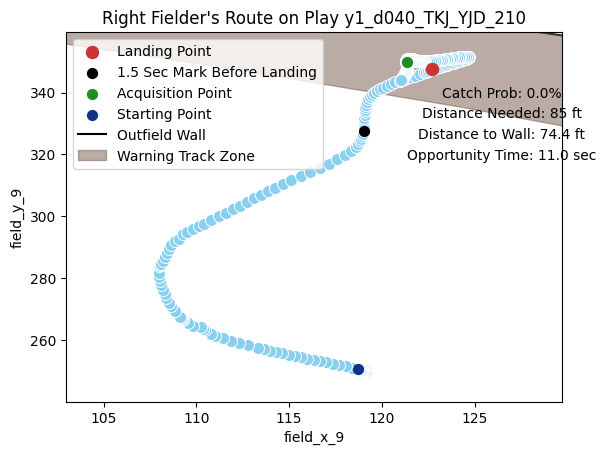

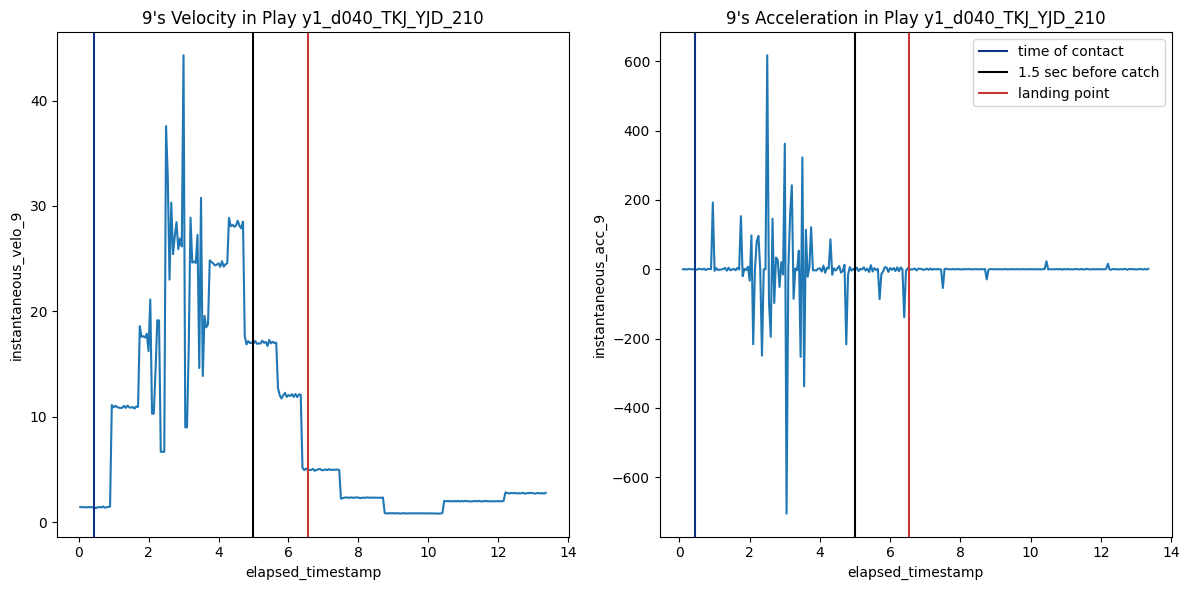

In [625]:
visual_trajectory(aggressive_data, 'y1_d040_TKJ_YJD_210')

### Distance to Closest Teammate

In [747]:
aggressive_data[(aggressive_data['game_str_id'] == 'y1_d098_MRJ_YJD_183') & (aggressive_data['event_code'].notna())]

,game_str_id,timestamp,at_bat,play_per_game,player_position,player_position_name,event_code,event_code_name,field_x_7,field_y_7,field_x_8,field_y_8,field_x_9,field_y_9,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day,timestamp_diff,elapsed_timestamp
501227,y1_d098_MRJ_YJD_183,5862.042,48,183.0,1.0,pitcher,1.0,pitch,-130.2126,265.2318,13.1049,317.4687,142.8519,254.4054,-1.633269,57.39690,5.529750,YJD,MRJ,year_1,day_098,0.00,0.00
501236,y1_d098_MRJ_YJD_183,5862.492,48,183.0,10.0,batter,4.0,ball hit into play,-130.0734,265.3695,13.6731,317.0289,142.2684,253.7178,0.133613,-1.01514,1.894302,YJD,MRJ,year_1,day_098,0.05,0.45
501270,y1_d098_MRJ_YJD_183,5864.192,48,183.0,255.0,"ball event with no player (e.g., ball bounce)",9.0,ball deflection,-135.6876,254.8869,5.6532,311.0793,137.2284,250.6416,-73.661700,92.61840,7.010730,YJD,MRJ,year_1,day_098,0.05,2.15
501286,y1_d098_MRJ_YJD_183,5864.992,48,183.0,255.0,"ball event with no player (e.g., ball bounce)",16.0,ball bounce,-137.2167,243.6708,0.1077,305.7870,135.2718,245.5917,-89.644200,116.31180,-0.771603,YJD,MRJ,year_1,day_098,0.05,2.95
501300,y1_d098_MRJ_YJD_183,5865.692,48,183.0,255.0,"ball event with no player (e.g., ball bounce)",16.0,ball bounce,-137.9835,231.0243,-4.6776,299.6490,133.7139,241.5345,-99.801900,131.11560,-0.119009,YJD,MRJ,year_1,day_098,0.05,3.65
501311,y1_d098_MRJ_YJD_183,5866.242,48,183.0,255.0,"ball event with no player (e.g., ball bounce)",16.0,ball bounce,-138.2397,218.6553,-8.7078,293.8716,132.5586,239.0202,-110.146800,142.57080,-0.715236,YJD,MRJ,year_1,day_098,0.05,4.20
501317,y1_d098_MRJ_YJD_183,5866.542,48,183.0,255.0,"ball event with no player (e.g., ball bounce)",16.0,ball bounce,-138.3744,211.4100,-10.9485,290.6361,131.9544,237.8367,-112.948500,147.67800,-0.278676,YJD,MRJ,year_1,day_098,0.05,4.50
501357,y1_d098_MRJ_YJD_183,5868.542,48,183.0,7.0,left field,2.0,ball acquired,-130.3659,169.2339,-23.7477,269.6241,127.4976,230.4885,-126.536400,172.01430,-1.047957,YJD,MRJ,year_1,day_098,0.05,6.50
501374,y1_d098_MRJ_YJD_183,5869.392,48,183.0,7.0,left field,3.0,throw (ball-in-play),-124.5009,162.0195,-27.1791,261.4512,126.3960,225.9294,-123.491400,164.35650,5.387100,YJD,MRJ,year_1,day_098,0.05,7.35
501393,y1_d098_MRJ_YJD_183,5870.342,48,183.0,255.0,"ball event with no player (e.g., ball bounce)",16.0,ball bounce,-120.6846,158.4435,-29.3994,254.6274,126.3144,218.1786,-28.939980,139.19580,-0.061136,YJD,MRJ,year_1,day_098,0.05,8.30


In [ ]:
## adding the closest teammate metrics to play_data_w_catch_probs
direction_closest_teammate_dict = metric_into_dict(aggressive_data, direction_closest_teammate)
dist_closest_teammate_dict = metric_into_dict(aggressive_data, dist_closest_teammate)
closest_teammate_dict = metric_into_dict(aggressive_data, closest_teammate)

direction_closest_teammate_df = pd.DataFrame.from_dict(direction_closest_teammate_dict, orient='index', columns=['direction_closest']).reset_index(names=['game_str_id']).copy()
dist_closest_teammate_df = pd.DataFrame.from_dict(dist_closest_teammate_dict, orient='index', columns=['dist_closest']).reset_index(names=['game_str_id']).copy()
closest_teammate_df = pd.DataFrame.from_dict(closest_teammate_dict, orient='index', columns=['closest_pos']).reset_index(names=['game_str_id']).copy()

play_data_w_catch_probs = play_data_w_catch_probs.merge(direction_closest_teammate_df, on='game_str_id', how='left').copy()
play_data_w_catch_probs = play_data_w_catch_probs.merge(dist_closest_teammate_df, on='game_str_id', how='left').copy()
play_data_w_catch_probs = play_data_w_catch_probs.merge(closest_teammate_df, on='game_str_id', how='left').copy()

### Getting the data ready for the Bayesian Analysis

In [ ]:
# play_data_w_catch_probs.to_csv('data_w_aggression.csv')

In [630]:
bayesian_data = pd.read_csv('jump_data.csv').iloc[:, 1:].copy()

In [650]:
bayesian_data

,game_str_id,distance_traveled_7,distance_traveled_8,distance_traveled_9,opportunity_time,hang_time,direction_angle_7,direction_angle_8,direction_angle_9,distance_needed_7,distance_needed_8,distance_needed_9,sprint_speed_7,sprint_speed_8,sprint_speed_9,distance_to_wall,launch_angle,exit_velo,is_out_catch,is_wall_ball,wall_ball_pos_z,closest_fielder_to_catch_point,player_attempt,whiffed_catch,reaction_7,reaction_8,reaction_9,burst_7,burst_8,burst_9,route_7,route_8,route_9,play_per_game,game_str,top_bottom_inning,left_field,center_field,right_field,distance_needed,distance_traveled,direction_angle,sprint_speed,reaction,burst,route,year,away_team,home_team,p_catch,pred_catch,difficulty_level,player_attempt_id,aggressive_attempt,expected_reaction_7,expected_reaction_8,expected_reaction_9,expected_burst_7,expected_burst_8,expected_burst_9,expected_route_7,expected_route_8,expected_route_9,expected_reaction,expected_burst,expected_route,reaction_vs_avg,burst_vs_avg,route_vs_avg,jump
0,y1_d001_CGA_QEA_240,10.851247,9.086522,2.155856,3.20,2.80,In Left,In Left,Back Left,12.824938,153.616141,242.682589,5.718944,3.534968,0.970684,69.884915,45.078858,94.377383,1.0,0,NaN,7.0,7.0,0.0,2.081028,3.788840,1.181984,8.322920,5.490593,1.015666,10.253843,9.387799,1.651421,240.0,y1_d001_CGA_QEA,0.0,CGA-1198,CGA-1547,CGA-1929,12.824938,10.851247,In Left,5.718944,2.081028,8.322920,10.253843,y1,CGA,QEA,0.95,1,1 Star,CGA-1198,0,4.453177,5.553635,4.848993,14.649579,21.393358,16.406302,16.580805,24.671004,18.524120,4.453177,14.649579,16.580805,-2.372149,-6.326659,-6.326962,-15.025770
1,y1_d001_CGA_QEA_256,40.752090,51.366908,41.555113,3.70,3.25,In Right,In Right,In Left,146.361479,71.571528,93.250419,16.544438,24.097861,16.662136,157.590665,39.835271,71.875289,0.0,0,NaN,8.0,8.0,0.0,6.087127,4.788836,5.478716,23.904072,29.014366,25.389299,29.319713,34.218190,30.931913,256.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,71.571528,51.366908,In Right,24.097861,4.788836,29.014366,34.218190,y1,CGA,QEA,0.10,0,5 Star,QEA-0235,0,6.027911,6.232013,6.141758,21.080042,23.882326,21.001806,25.843257,28.457633,25.648587,6.232013,23.882326,28.457633,-1.443177,5.132040,5.760557,9.449420
2,y1_d001_CGA_QEA_195,5.931540,17.049194,19.783084,2.45,2.05,In Right,In Right,In,214.763726,173.878553,113.523389,3.633669,11.467247,15.454587,197.832670,56.395341,70.778037,0.0,0,NaN,9.0,9.0,0.0,3.171357,6.864249,4.589234,2.881922,11.467247,15.454587,5.968212,15.963336,18.805976,195.0,y1_d001_CGA_QEA,0.0,CGA-1198,CGA-1547,CGA-1929,113.523389,19.783084,In,15.454587,4.589234,15.454587,18.805976,y1,CGA,QEA,0.00,0,5 Star,CGA-1929,0,6.312130,6.141955,6.841919,16.932673,20.986776,18.450323,23.306001,26.546854,25.499023,6.841919,18.450323,25.499023,-2.252685,-2.995735,-6.693048,-11.941468
3,y1_d001_CGA_QEA_262,22.839094,5.672331,2.289652,2.50,2.05,In,In Left,In Left,80.313315,165.692225,232.381521,15.870060,3.218863,1.545573,127.607913,52.200602,90.253353,0.0,0,NaN,7.0,7.0,0.0,6.873703,3.139336,1.626320,16.468740,3.361939,0.780074,23.022843,6.304819,2.222111,262.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,80.313315,22.839094,In,15.870060,6.873703,16.468740,23.022843,y1,CGA,QEA,0.00,0,5 Star,QEA-0249,0,6.283961,6.486610,6.703232,19.446925,24.054858,20.900528,25.053973,29.522455,26.965259,6.283961,19.446925,25.053973,0.589742,-2.978185,-2.031130,-4.419573
4,y1_d001_CGA_QEA_274,16.153562,56.441888,33.625889,5.10,4.65,In Right,In Right,Back Left,215.824188,89.689035,29.527484,3.972489,16.521860,12.682216,90.206290,39.664283,73.064776,1.0,0,NaN,9.0,9.0,0.0,2.245274,4.998017,5.315608,6.133556,23.692122,17.504153,7.464141,28.981189,21.710668,274.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,29.527484,33.625889,Back Left,12.682216,5.315608,17.504153,21.710668,y1,CGA,QEA,0.95,1,1 Star,QEA-0252,0,4.204236,3.779314,4.326016,18.556284,17.160631,18.429415,20.051581,17.758982,19.616688,4.326016,18.429415,19.616688,0.989592,-0.925262,2.093980,2.158310
...,...,...,...,...,...,...,...,...,...,...,...,.

In [ ]:
## finds each component of Jump and compares it to the expectation for that component (what the average player would do)
bayesian_data = attempt_metric_creator(bayesian_data, 'expected_reaction').copy()
bayesian_data = attempt_metric_creator(bayesian_data, 'expected_burst').copy()
bayesian_data = attempt_metric_creator(bayesian_data, 'expected_route').copy()

bayesian_data.loc[:, 'reaction_vs_avg'] = bayesian_data['reaction'] - bayesian_data['expected_reaction']
bayesian_data.loc[:, 'burst_vs_avg'] = bayesian_data['burst'] - bayesian_data['expected_burst']
bayesian_data.loc[:, 'route_vs_avg'] = bayesian_data['route'] - bayesian_data['expected_route']
bayesian_data.loc[:, 'jump'] = bayesian_data['reaction_vs_avg'] + bayesian_data['burst_vs_avg'] + bayesian_data['route_vs_avg']

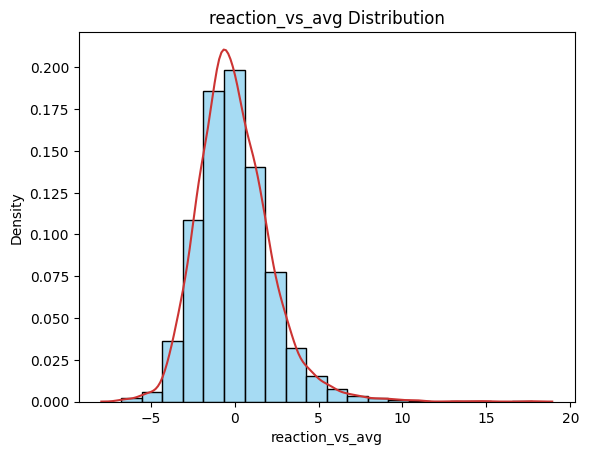

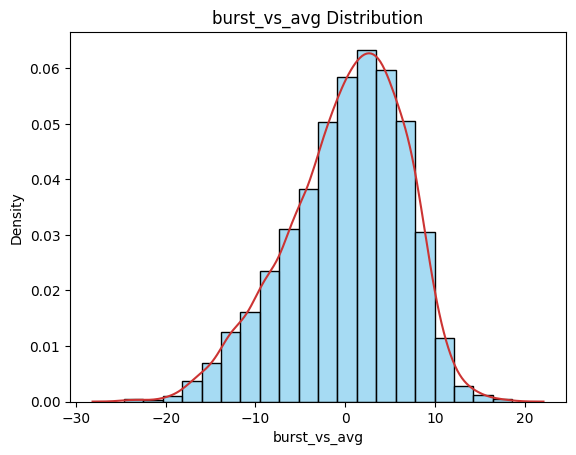

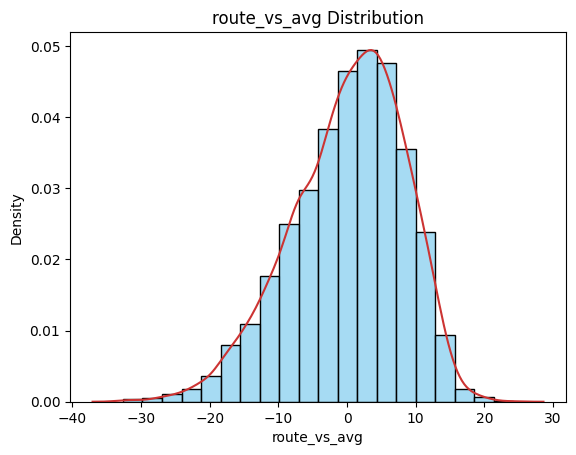

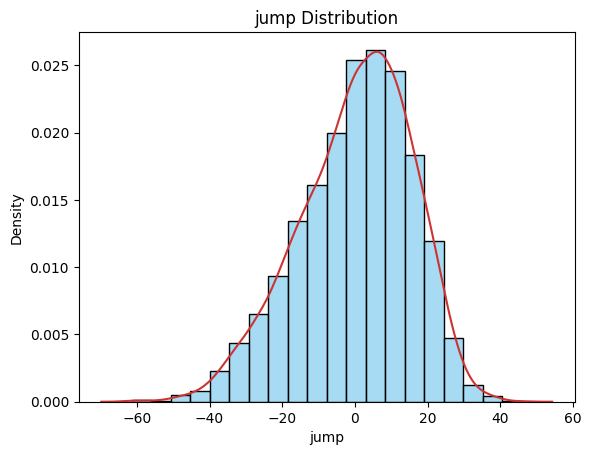

In [647]:
jump_hists(bayesian_data, 'reaction_vs_avg')
jump_hists(bayesian_data, 'burst_vs_avg')
jump_hists(bayesian_data, 'route_vs_avg')
jump_hists(bayesian_data, 'jump')

In [651]:
def agg_attempt_hist(df: pd.DataFrame, column: str) -> None:
    """
    Displays overlapping histograms between aggressive attempts and not for some column
    
    Arguments: column: is some quantitative column in df
    """
    df = df.copy()

    plt.figure(figsize=(8, 4))
    plt.hist(df[df['aggressive_attempt'] == 0][column], bins=25, alpha=0.7, label='Aggressive Attempt == 0', color='#CC3433', density=True)
    plt.hist(df[df['aggressive_attempt'] == 1][column], bins=25, alpha=0.7, label='Aggressive Attempt == 1', color='#89CFF0', density=True)
    plt.xlabel(f"{column.replace('_', ' ')}")
    plt.ylabel('Density')
    plt.title(f"{column.replace('_', ' ')} Comparison Between Aggressive Plays and Not")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

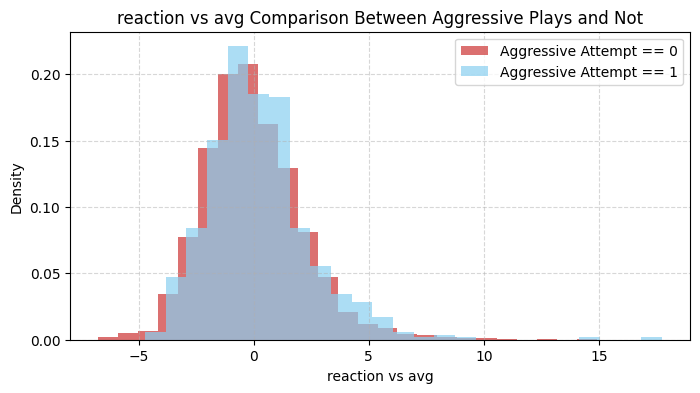

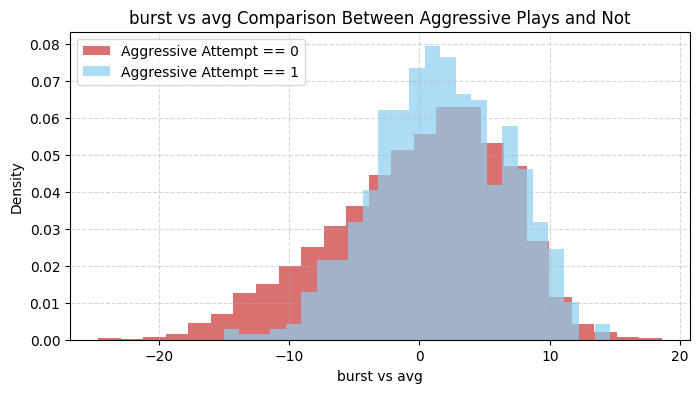

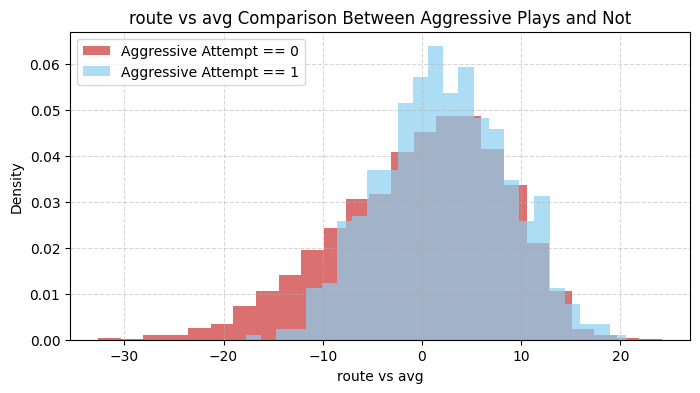

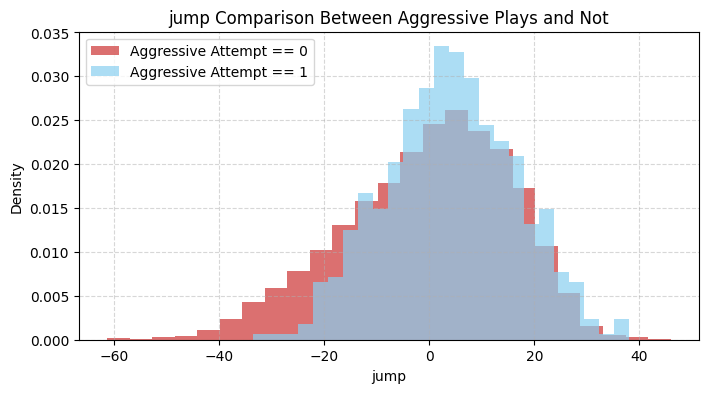

In [652]:
agg_attempt_hist(bayesian_data, 'reaction_vs_avg')
agg_attempt_hist(bayesian_data, 'burst_vs_avg')
agg_attempt_hist(bayesian_data, 'route_vs_avg')
agg_attempt_hist(bayesian_data, 'jump')

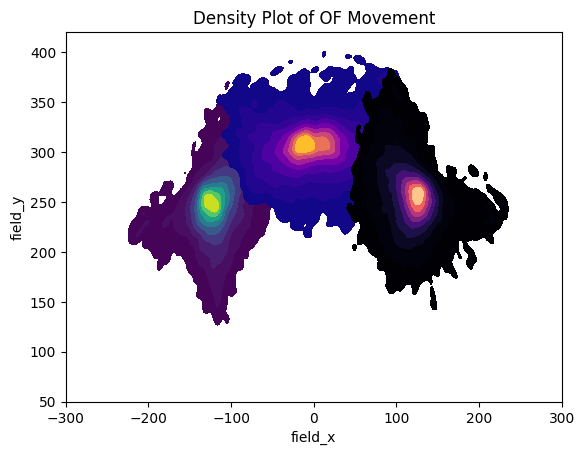

In [657]:
plt.figure()
sns.kdeplot(data=aggressive_data, x="field_x_7", y="field_y_7", fill=True, cmap="viridis", levels=10)
sns.kdeplot(data=aggressive_data, x="field_x_8", y="field_y_8", fill=True, cmap="plasma", levels=10)
sns.kdeplot(data=aggressive_data, x="field_x_9", y="field_y_9", fill=True, cmap="magma", levels=10)
plt.title("Density Plot of OF Movement")
plt.xlabel("field_x")
plt.ylabel("field_y")
plt.xlim(-300, 300)
plt.ylim(50, 420)
plt.show()

### Bayesian Analysis

In [594]:
play_data_w_catch_probs

,game_str_id,distance_traveled_7,distance_traveled_8,distance_traveled_9,opportunity_time,hang_time,direction_angle_7,direction_angle_8,direction_angle_9,distance_needed_7,distance_needed_8,distance_needed_9,sprint_speed_7,sprint_speed_8,sprint_speed_9,distance_to_wall,launch_angle,exit_velo,is_out_catch,is_wall_ball,wall_ball_pos_z,closest_fielder_to_catch_point,player_attempt,whiffed_catch,reaction_7,reaction_8,reaction_9,burst_7,burst_8,burst_9,route_7,route_8,route_9,play_per_game,game_str,top_bottom_inning,left_field,center_field,right_field,distance_needed,distance_traveled,direction_angle,sprint_speed,reaction,burst,route,year,away_team,home_team,p_catch,pred_catch,difficulty_level,player_attempt_id,aggressive_attempt
0,y1_d001_CGA_QEA_240,10.851247,9.086522,2.155856,3.20,2.80,In Left,In Left,Back Left,12.824938,153.616141,242.682589,5.718944,3.534968,0.970684,69.884915,45.078858,94.377383,1.0,0,NaN,7.0,7.0,0.0,2.081028,3.788840,1.181984,8.322920,5.490593,1.015666,10.253843,9.387799,1.651421,240.0,y1_d001_CGA_QEA,0.0,CGA-1198,CGA-1547,CGA-1929,12.824938,10.851247,In Left,5.718944,2.081028,8.322920,10.253843,y1,CGA,QEA,0.95,1,1 Star,CGA-1198,0
1,y1_d001_CGA_QEA_256,40.752090,51.366908,41.555113,3.70,3.25,In Right,In Right,In Left,146.361479,71.571528,93.250419,16.544438,24.097861,16.662136,157.590665,39.835271,71.875289,0.0,0,NaN,8.0,8.0,0.0,6.087127,4.788836,5.478716,23.904072,29.014366,25.389299,29.183446,34.206121,30.930725,256.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,71.571528,51.366908,In Right,24.097861,4.788836,29.014366,34.206121,y1,CGA,QEA,0.10,0,5 Star,QEA-0235,0
2,y1_d001_CGA_QEA_195,5.931540,17.049194,19.783084,2.45,2.05,In Right,In Right,In,214.763726,173.878553,113.523389,3.633669,11.467247,15.454587,197.832670,56.395341,70.778037,0.0,0,NaN,9.0,9.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,195.0,y1_d001_CGA_QEA,0.0,CGA-1198,CGA-1547,CGA-1929,113.523389,19.783084,In,15.454587,NaN,NaN,NaN,y1,CGA,QEA,0.00,0,5 Star,CGA-1929,0
3,y1_d001_CGA_QEA_262,22.839094,5.672331,2.289652,2.50,2.05,In,In Left,In Left,80.313315,165.692225,232.381521,15.870060,3.218863,1.545573,127.607913,52.200602,90.253353,0.0,0,NaN,7.0,7.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,262.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,80.313315,22.839094,In,15.870060,NaN,NaN,NaN,y1,CGA,QEA,0.00,0,5 Star,QEA-0249,0
4,y1_d001_CGA_QEA_274,16.153562,56.441888,33.625889,5.10,4.65,In Right,In Right,Back Left,215.824188,89.689035,29.527484,3.972489,16.521860,12.682216,90.206290,39.664283,73.064776,1.0,0,NaN,9.0,9.0,0.0,2.245274,4.998017,5.315608,6.133556,23.692122,17.504153,7.464141,28.981189,21.710668,274.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,29.527484,33.625889,Back Left,12.682216,5.315608,17.504153,21.710668,y1,CGA,QEA,0.95,1,1 Star,QEA-0252,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5302,y2_d098_YJD_RZQ_31,58.934871,43.425153,51.200365,5.55,5.10,In Left,In Left,In Left,58.501942,191.678279,297.083654,17.003829,11.716270,14.456756,12.443687,47.492657,83.093814,1.0,0,NaN,7.0,7.0,0.0,4.961152,6.299032,2.449183,23.929984,9.626690,12.719698,28.841153,15.513497,14.202365,31.0,y2_d098_YJD_RZQ,0.0,YJD-0185,YJD-0019,YJD-0397,58.501942,58.934871,In Left,17.003829,4.961152,23.929984,28.841153,y2,YJD,RZQ,0.95,1,1 Star,YJD-0185,0
5303,y2_d098_YJD_RZQ_27,15.630649,54.975692,64.723286,4.10,3.65,Back Right,In Right,In Left,191.243692,92.040877,64.570861,5.352801,18.570224,25.881714,116.428579,43.966029,76.873693,1.0,0,NaN,9.0,9.0,0.0,3.698580,8.670381,4.644516,7.849271,26.731749,30.475450,11.449862,35.014613,35.615767,27.0,y2_d098_YJD_RZQ,0.0,YJD-0185,YJD-0019,YJD-0397,64.570861,64.723286,In Left,25.881714,4.644516,30.475450,35.615767,y2,YJD,RZQ,0.55,1,3 Star,YJD-0397,0
5304,y2_d098_YJD_RZQ_13,32.003407,32.533982,32.870219,3.10,2.65,In Right,In,In Left,142.573368,121.095